In [195]:
import nltk
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB , BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [49]:
import pandas as pd

data = pd.read_csv(
    r"C:\Users\rahul\Documents\Programming\Github Projects\Classic-ML-Projects\email-spam-classifier\data\spam.csv",
    encoding="latin-1"
)

Data Cleaning

In [50]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [51]:
data.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [52]:
temp_data = data[['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']].dropna(how='all').head(10)
temp_data

,Unnamed: 2,Unnamed: 3,Unnamed: 4
95,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
281,the person is definitely special for u..... B...,why to miss them,"just Keep-in-touch\"" gdeve.."""
444,HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE ...,NaN,NaN
671,"wanted to say hi. HI!!!\"" Stop? Send STOP to ...",NaN,NaN
710,"this wont even start........ Datz confidence..""",NaN,NaN
899,PO Box 5249,"MK17 92H. 450Ppw 16""",NaN
1038,GN,GE,"GNT:-)"""
1127,".;-):-D""",NaN,NaN
1266,just been in bedbut mite go 2 thepub l8tr if u...,NaN,NaN
1384,"bt not his girlfrnd... G o o d n i g h t . . .@""",NaN,NaN


In [53]:
data['v2'] = data[['v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']].fillna('').agg(' '.join, axis=1)

In [54]:
data['v2'] = data['v2'].str.strip()

In [55]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [56]:
data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [57]:
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [58]:
data.rename(columns={'v1':'label'}, inplace=True)

In [59]:
data.rename(columns={'v2':'text'}, inplace=True)

In [60]:
data.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [61]:
data = data[['text', 'label']]

In [62]:
print(data.head())
print(data.shape)

                                                text label
0  Go until jurong point, crazy.. Available only ...   ham
1                      Ok lar... Joking wif u oni...   ham
2  Free entry in 2 a wkly comp to win FA Cup fina...  spam
3  U dun say so early hor... U c already then say...   ham
4  Nah I don't think he goes to usf, he lives aro...   ham
(5572, 2)


In [63]:
data.duplicated().sum()

np.int64(414)

In [64]:
data = data.drop_duplicates(keep='first')

In [65]:
data.duplicated().sum()

np.int64(0)

In [66]:
data['label'] = data['label'].apply(lambda x: 1 if x=='spam' else 0)

In [67]:
data.head()

,text,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


#--------------------EDA--------------------#

In [68]:
data['label'].value_counts()

label
0    4516
1     642
Name: count, dtype: int64

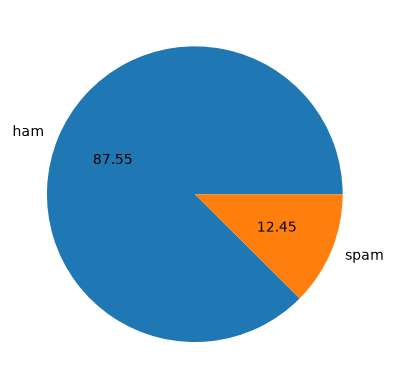

In [69]:
plt.pie(data['label'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

#-----------------Data Preprocessing--------------#

In [70]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [71]:
ps = PorterStemmer()

In [72]:
def data_preprocessing(text):
    text = text.lower()
    text = nltk.word_tokenize(text=text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [73]:
data['transformed_text'] = data['text'].apply(data_preprocessing)

In [74]:
data = data[['text', 'transformed_text', 'label']]

In [75]:
data.head()

,text,transformed_text,label
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...,0
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...,1
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though,0


#-------------------Vectorization-----------------#

In [155]:
td_idf = TfidfVectorizer()

In [156]:
X = td_idf.fit_transform(data['transformed_text']).toarray()

In [157]:
y = data['label'].values

In [158]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#------------------Model Building---------------#

In [159]:
model_1 = GaussianNB()
model_mnb = MultinomialNB()
model_3 = BernoulliNB()

In [160]:
model_1.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[3624., 502.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.88,0.12]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,6.377e-12
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6787
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 6787)","[[0.,0.,0.,...,0.,0.,0.], [0.,0.,0.,...,0.,0.,0.]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 6787)","[[0.,0.,0.,...,0.,0.,0.], [0.,0.,0.,...,0.,0.,0.]]"


In [161]:
y_train_pred = model_1.predict(X_train)

In [162]:
train_score = accuracy_score(y_train, y_train_pred)

In [163]:
train_score

0.9185651963160446

In [164]:
y_test_pred = model_1.predict(X_test)

In [165]:
test_accuracy_score = accuracy_score(y_test, y_test_pred)

In [166]:
test_accuracy_score

0.8875968992248062

In [167]:
test_precision_score = precision_score(y_test, y_test_pred)

In [168]:
test_precision_score

0.5504201680672269

In [169]:
model_mnb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3624., 502.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.11]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 6787)","[[ 0. , 0. , 0. ,..., 0.26, 0.34,14.06], [ 0.33, 0.31, 0.39,..., 0. , 0. , 0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 6787)","[[-9.66,-9.66,-9.66,...,-9.43,-9.37,-6.94], [-8.77,-8.79,-8.72,...,-9.05,-9.05,-9.05]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6787


In [170]:
y_train_pred_2 = model_mnb.predict(X_train)
train_score_2 = accuracy_score(y_train, y_train_pred_2)
print(train_score_2)

0.9684924866698982


In [171]:
y_test_pred_2 = model_mnb.predict(X_test)
test_accuracy_score_2 = accuracy_score(y_test, y_test_pred_2)
print(test_accuracy_score_2)

0.9660852713178295


In [172]:
test_precision_score_2 = precision_score(y_test, y_test_pred_2)
print(test_precision_score_2)

1.0


In [196]:
test_recall_score_2 = recall_score(y_test, y_test_pred_2)
print(test_recall_score_2)

0.75


In [197]:
test_f1_score_2 = f1_score(y_test, y_test_pred_2)
print(test_f1_score_2)

0.8571428571428571


In [173]:
model_3.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3624., 502.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.13,-2.11]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 6787)","[[ 0., 0., 0.,..., 1., 1.,35.], [ 1., 1., 1.,..., 0., 0., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 6787)","[[-8.2 ,-8.2 ,-8.2 ,...,-7.5 ,-7.5 ,-4.61], [-5.53,-5.53,-5.53,...,-6.22,-6.22,-6.22]]"


In [174]:
y_train_pred_3 = model_3.predict(X_train)

In [175]:
train_score_3 = accuracy_score(y_train, y_train_pred_3)
print(train_score)

0.9185651963160446


In [176]:
y_test_pred_3 = model_3.predict(X_test)
test_score_3 = accuracy_score(y_test, y_test_pred_3)
print(train_score)

0.9185651963160446


In [177]:
test_precision_score_3 = precision_score(y_test, y_test_pred_3)
print(test_precision_score_3)

0.9572649572649573


Note : Will use multinomialNB as default and baseline model

In [178]:
model_LR = LogisticRegression()

In [179]:
model_LR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [180]:
y_pred_lr = model_LR.predict(X_test)

In [181]:
lr_accuracy_score = accuracy_score(y_test, y_pred_lr)
print(lr_accuracy_score)

0.9563953488372093


In [182]:
lr_precision_score = precision_score(y_test, y_pred_lr)
print(lr_precision_score)

0.9896907216494846


In [198]:
lr_recall_score = recall_score(y_test, y_pred_lr)
print(lr_recall_score)

0.6857142857142857


In [199]:
lr_f1_score = f1_score(y_test, y_pred_lr)
print(lr_f1_score)

0.810126582278481


MultinomialNB => {accuracy : 0.96, precision : 1.0, recall : 0.75, f1 : 0.85}

LogisticRegression => {accuracy : 0.95, precision : 0.98, recall : 0.68, f1 : 0.81}


In [183]:
model_svm = LinearSVC()
model_svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [184]:
y_pred_svm = model_svm.predict(X_test)

In [185]:
svm_accuracy_score = accuracy_score(y_test, y_pred_svm)
print(svm_accuracy_score)

0.9844961240310077


In [186]:
svm_precision_score = precision_score(y_test, y_pred_svm)
print(svm_precision_score)

0.9696969696969697


In [200]:
svm_recall_score = recall_score(y_test, y_pred_svm)
print(svm_recall_score)

0.9142857142857143


In [201]:
svm_f1_score = f1_score(y_test, y_pred_svm)
print(svm_f1_score)

0.9411764705882353


MultinomialNB => {accuracy : 0.96, precision : 1.0, recall : 0.75, f1 : 0.85}

LogisticRegression => {accuracy : 0.95, precision : 0.98, recall : 0.68, f1 : 0.81}

LinearSVM => {accuracy : 0.98, precision : 0.96, recall : 0.91, f1 : 0.94}

In [189]:
model_rf = RandomForestClassifier()

In [190]:
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [191]:
y_pred_rf = model_rf.predict(X_test)

In [193]:
rf_accuracy_score = accuracy_score(y_test, y_pred_rf)
print(rf_accuracy_score)

0.9786821705426356


In [194]:
rf_precision_score = precision_score(y_test, y_pred_rf)
print(rf_precision_score)

0.9916666666666667


In [202]:
rf_recall_score = recall_score(y_test, y_pred_rf)
print(rf_recall_score)

0.85


In [203]:
rf_f1_score = f1_score(y_test, y_pred_rf)
print(rf_f1_score)

0.9153846153846154


MultinomialNB => {accuracy : 0.96, precision : 1.0, recall : 0.75, f1 : 0.85}

LogisticRegression => {accuracy : 0.95, precision : 0.98, recall : 0.68, f1 : 0.81}

LinearSVM => {accuracy : 0.98, precision : 0.96, recall : 0.91, f1 : 0.94}

RandomForestClassifier => {accuracy : 0.97, precision : 0.99, recall : 0.85, f1 : 0.91}

LinearSVM is performing the best wit overall balance of acuracy, precision, recall and F1 score!